In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from chembl_webresource_client.new_client import new_client

print("All imports OK")

All imports OK


In [2]:
# Fetch CDK2 bioactivity data from ChEMBL
activity = new_client.activity
target = new_client.target

# CDK2 ChEMBL ID
cdk2_target = target.search('CDK2')[0]
print(f"Target: {cdk2_target['pref_name']} | ChEMBL ID: {cdk2_target['target_chembl_id']}")

# Pull IC50 data
res = activity.filter(
    target_chembl_id=cdk2_target['target_chembl_id'],
    standard_type='IC50',
    standard_relation='=',
    assay_type='B'
).only([
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'pchembl_value',
    'assay_chembl_id'
])

df_raw = pd.DataFrame(res)
print(f"Raw records: {len(df_raw)}")
df_raw.head()

Target: CDK2/CDK4 | ChEMBL ID: CHEMBL3038517
Raw records: 0


""


In [3]:
# See all targets returned by the search
targets = target.search('CDK2')
for i, t in enumerate(targets):
    print(f"{i} | {t['target_chembl_id']} | {t['pref_name']} | {t['target_type']}")

0 | CHEMBL3038517 | CDK2/CDK4 | PROTEIN FAMILY
1 | CHEMBL4106185 | CDK2/CDK4 | PROTEIN FAMILY
2 | CHEMBL4106186 | CDK2/CDK9 | PROTEIN FAMILY
3 | CHEMBL3038469 | CDK2/Cyclin A2 | PROTEIN COMPLEX
4 | CHEMBL3038470 | CDK2/Cyclin A1 | PROTEIN COMPLEX
5 | CHEMBL4106152 | CDK2/Cyclin O | PROTEIN COMPLEX
6 | CHEMBL4523633 | CDK2/Cyclin-E2 | PROTEIN COMPLEX
7 | CHEMBL4523634 | CDK2/Cyclin-Y | PROTEIN COMPLEX
8 | CHEMBL4888454 | CDK2/Cyclin C | PROTEIN COMPLEX
9 | CHEMBL301 | Cyclin-dependent kinase 2 | SINGLE PROTEIN
10 | CHEMBL6010 | Cyclin-dependent kinase 2-associated protein 2 | SINGLE PROTEIN
11 | CHEMBL4106153 | CDK2/Bovine cyclin A | PROTEIN COMPLEX
12 | CHEMBL4523689 | Protein cereblon/Cyclin-dependent kinase 2 | PROTEIN-PROTEIN INTERACTION
13 | CHEMBL4802027 | Protein cereblon/Cyclin-dependent kinase 2 | PROTEIN-PROTEIN INTERACTION
14 | CHEMBL5578 | Cyclin-dependent kinase 2-associated protein 1 | SINGLE PROTEIN
15 | CHEMBL1907605 | Cyclin-dependent kinase 2/cyclin E1 | PROTEIN COMPLE

In [4]:
# Pull IC50 data for CDK2 SINGLE PROTEIN (CHEMBL301)
res = activity.filter(
    target_chembl_id='CHEMBL301',
    standard_type='IC50',
    standard_relation='=',
    assay_type='B'
).only([
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'pchembl_value',
    'assay_chembl_id'
])

df_raw = pd.DataFrame(res)
print(f"Raw records: {len(df_raw)}")
df_raw.head()

Raw records: 2744


,assay_chembl_id,canonical_smiles,molecule_chembl_id,pchembl_value,standard_units,standard_value,units,value
0,CHEMBL660784,COc1ccc(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)cc1,CHEMBL101052,4.44,nM,36000.0,uM,36.0
1,CHEMBL661128,O=C(Nc1n[nH]c2nc(-c3ccc(O)c(Br)c3)ccc12)C1CC1,CHEMBL260416,8.70,nM,2.0,nM,2.0
2,CHEMBL661130,CC(C)C(CO)Nc1nc(NCc2cccc(O)c2)c2ncn(C(C)C)c2n1,CHEMBL84944,7.52,nM,30.0,uM,0.03
3,CHEMBL660784,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(N(CCCC(F)(F)F)c3...,CHEMBL419720,6.70,nM,200.0,uM,0.2
4,CHEMBL661128,O=C(Nc1n[nH]c2cc(-c3ccc[nH]3)ccc12)C1CC1,CHEMBL260929,6.30,nM,497.0,nM,497.0


In [5]:
# Clean and filter
df = df_raw.copy()

# Drop rows missing critical fields
df = df.dropna(subset=['canonical_smiles', 'pchembl_value'])

# Keep only nM units
df = df[df['standard_units'] == 'nM']

# Convert pchembl_value to float
df['pchembl_value'] = df['pchembl_value'].astype(float)

# Remove duplicates - keep median pIC50 per unique SMILES
df = df.groupby('canonical_smiles', as_index=False)['pchembl_value'].median()

# Basic sanity filter - remove extreme outliers
df = df[(df['pchembl_value'] >= 3) & (df['pchembl_value'] <= 12)]

print(f"Records after cleaning: {len(df)}")
print(f"\npIC50 distribution:")
print(df['pchembl_value'].describe())

Records after cleaning: 2001

pIC50 distribution:
count    2001.000000
mean        6.584640
std         1.157905
min         3.460000
25%         5.720000
50%         6.600000
75%         7.470000
max         9.520000
Name: pchembl_value, dtype: float64


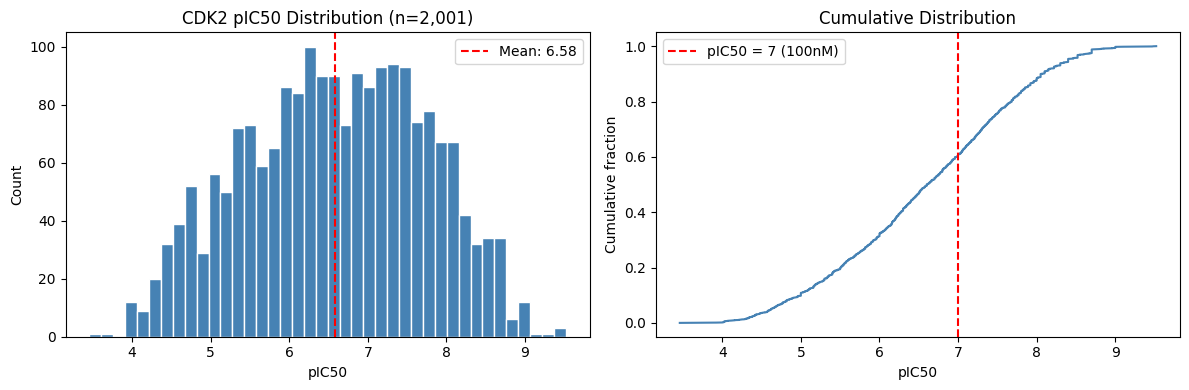

Plot saved


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# pIC50 distribution
axes[0].hist(df['pchembl_value'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].set_title('CDK2 pIC50 Distribution (n=2,001)')
axes[0].axvline(df['pchembl_value'].mean(), color='red', linestyle='--', label=f"Mean: {df['pchembl_value'].mean():.2f}")
axes[0].legend()

# Cumulative distribution
sorted_vals = df['pchembl_value'].sort_values()
axes[1].plot(sorted_vals.values, np.linspace(0, 1, len(sorted_vals)), color='steelblue')
axes[1].set_xlabel('pIC50')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('Cumulative Distribution')
axes[1].axvline(7.0, color='red', linestyle='--', label='pIC50 = 7 (100nM)')
axes[1].legend()

plt.tight_layout()
plt.savefig('pIC50_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [7]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Define both outside the loop
descriptor_names = [
    'MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors',
    'TPSA', 'NumRotatableBonds', 'RingCount',
    'NumAromaticRings', 'FractionCSP3', 'NumHeteroatoms'
]
generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

print("Computing features...")
features = []
valid_idx = []

for i, smi in enumerate(df['canonical_smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    fp_array = np.array(generator.GetFingerprint(mol))
    physchem = np.array(calc.CalcDescriptors(mol))
    features.append(np.concatenate([fp_array, physchem]))
    valid_idx.append(i)

X = np.array(features)
y = df['pchembl_value'].iloc[valid_idx].values

print(f"Feature matrix shape: {X.shape}")
print(f"Valid compounds: {len(y)}")
print(f"Features per compound: {X.shape[1]}")

Computing features...
Feature matrix shape: (2001, 1034)
Valid compounds: 2001
Features per compound: 1034


In [8]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict

def get_scaffold(smiles):
    """Get Murcko scaffold SMILES for a compound."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

# Assign scaffolds
print("Computing scaffolds...")
scaffolds = defaultdict(list)
for i, smi in enumerate(df['canonical_smiles'].iloc[valid_idx]):
    scaffold = get_scaffold(smi)
    if scaffold is not None:
        scaffolds[scaffold].append(i)

print(f"Unique scaffolds: {len(scaffolds)}")

# Sort scaffolds by size (largest first)
scaffold_sets = sorted(scaffolds.values(), key=lambda x: len(x), reverse=True)

# Split 80/20 - keep whole scaffolds together
train_idx, test_idx = [], []
train_cutoff = int(0.8 * len(valid_idx))

for scaffold_set in scaffold_sets:
    if len(train_idx) < train_cutoff:
        train_idx.extend(scaffold_set)
    else:
        test_idx.extend(scaffold_set)

X_train = X[train_idx]
X_test  = X[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

print(f"\nTrain: {len(y_train)} compounds")
print(f"Test:  {len(y_test)} compounds")
print(f"Train pIC50 range: {y_train.min():.2f} - {y_train.max():.2f}")
print(f"Test pIC50 range:  {y_test.min():.2f} - {y_test.max():.2f}")

Computing scaffolds...
Unique scaffolds: 857

Train: 1600 compounds
Test:  401 compounds
Train pIC50 range: 4.01 - 9.52
Test pIC50 range:  3.46 - 8.82


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb

# --- Random Forest ---
print("Training Random Forest...")
rf = RandomForestRegressor(
    n_estimators=200,
    max_features=0.3,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
print(f"RF  — R²: {rf_r2:.3f} | RMSE: {rf_rmse:.3f} pIC50 units")

# --- XGBoost ---
print("\nTraining XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_r2   = r2_score(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
print(f"XGB — R²: {xgb_r2:.3f} | RMSE: {xgb_rmse:.3f} pIC50 units")

print(f"\nWinner: {'XGBoost' if xgb_r2 > rf_r2 else 'Random Forest'}")

Training Random Forest...
RF  — R²: 0.362 | RMSE: 0.980 pIC50 units

Training XGBoost...
XGB — R²: 0.389 | RMSE: 0.959 pIC50 units

Winner: XGBoost


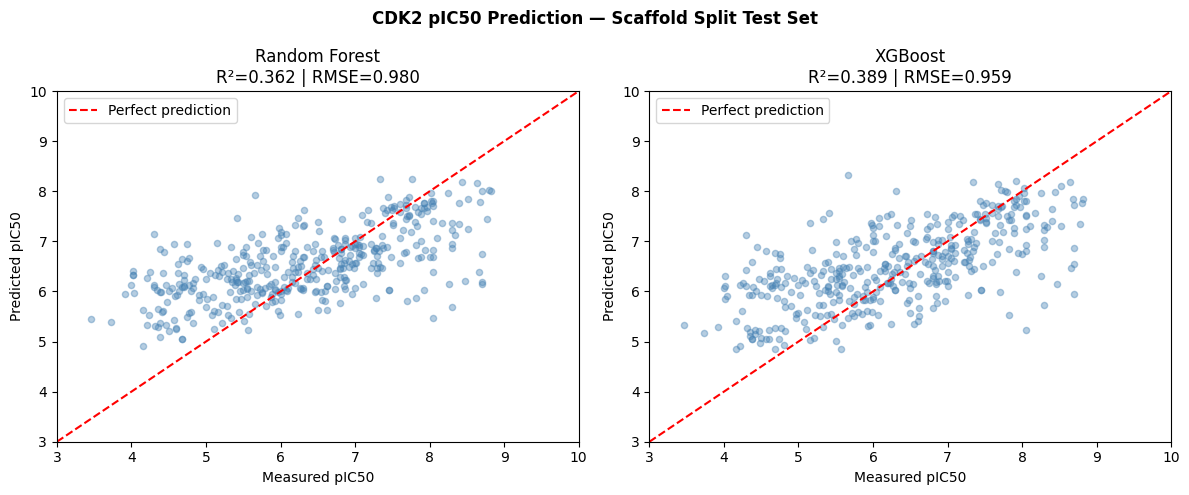

Plot saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in zip(
    axes,
    [rf_pred, xgb_pred],
    ['Random Forest', 'XGBoost']
):
    ax.scatter(y_test, pred, alpha=0.4, s=20, color='steelblue')
    ax.plot([3, 10], [3, 10], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Measured pIC50')
    ax.set_ylabel('Predicted pIC50')
    ax.set_title(f'{title}\nR²={r2_score(y_test, pred):.3f} | RMSE={mean_squared_error(y_test, pred)**0.5:.3f}')
    ax.set_xlim(3, 10)
    ax.set_ylim(3, 10)
    ax.legend()

plt.suptitle('CDK2 pIC50 Prediction — Scaffold Split Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [11]:
import shap

print("Computing SHAP values (this may take 2-3 minutes)...")

# Use XGBoost as it performed better
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Feature names - ECFP4 bits + physicochemical
feature_names = [f'ECFP4_bit_{i}' for i in range(1024)] + descriptor_names

print(f"SHAP values shape: {shap_values.shape}")
print("Done")

Computing SHAP values (this may take 2-3 minutes)...
SHAP values shape: (401, 1034)
Done


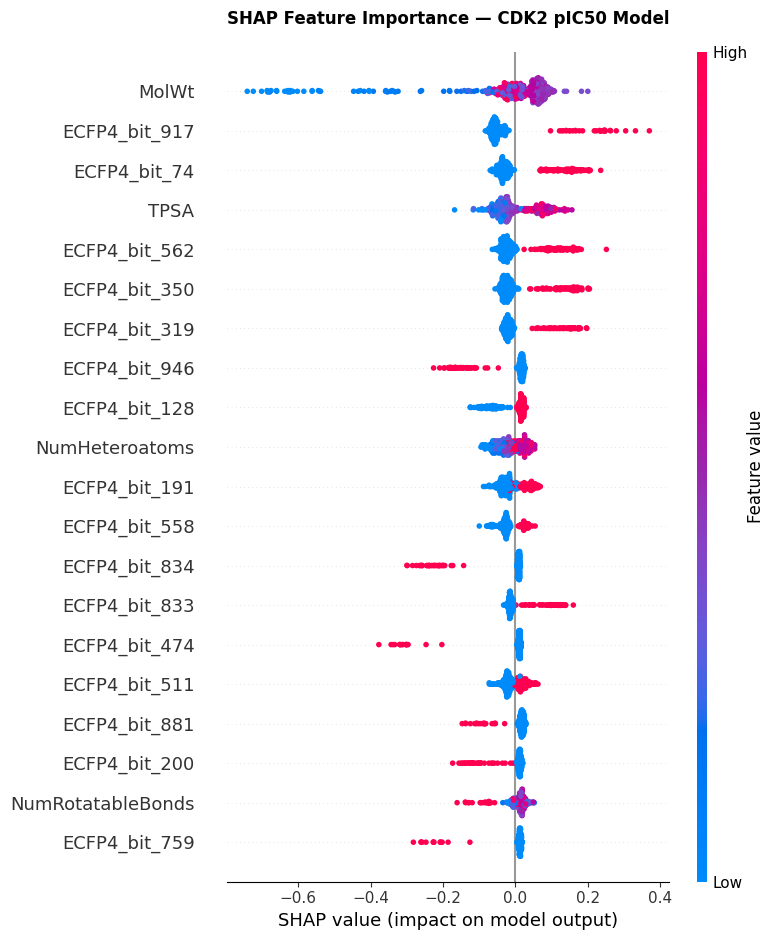

Plot saved


In [12]:
# SHAP Summary Plot - top 20 most important features
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — CDK2 pIC50 Model', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [13]:
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
from IPython.display import display
import matplotlib.pyplot as plt

# Find which compounds have each important bit set
important_bits = [917, 74, 562, 350]

for bit in important_bits:
    # Find compounds where this bit is set
    bit_set = [i for i, smi in enumerate(df['canonical_smiles'].iloc[valid_idx]) 
               if X[i, bit] == 1]
    
    print(f"\nECFP4_bit_{bit}: present in {len(bit_set)} compounds "
          f"({100*len(bit_set)/len(valid_idx):.1f}% of dataset)")
    
    # Mean pIC50 for compounds with vs without this bit
    mean_with    = y[bit_set].mean()
    mean_without = y[[i for i in range(len(y)) if i not in bit_set]].mean()
    print(f"  Mean pIC50 WITH bit:    {mean_with:.2f}")
    print(f"  Mean pIC50 WITHOUT bit: {mean_without:.2f}")


ECFP4_bit_917: present in 302 compounds (15.1% of dataset)
  Mean pIC50 WITH bit:    7.28
  Mean pIC50 WITHOUT bit: 6.46

ECFP4_bit_74: present in 384 compounds (19.2% of dataset)
  Mean pIC50 WITH bit:    6.99
  Mean pIC50 WITHOUT bit: 6.49

ECFP4_bit_562: present in 456 compounds (22.8% of dataset)
  Mean pIC50 WITH bit:    7.01
  Mean pIC50 WITHOUT bit: 6.46

ECFP4_bit_350: present in 411 compounds (20.5% of dataset)
  Mean pIC50 WITH bit:    7.24
  Mean pIC50 WITHOUT bit: 6.41


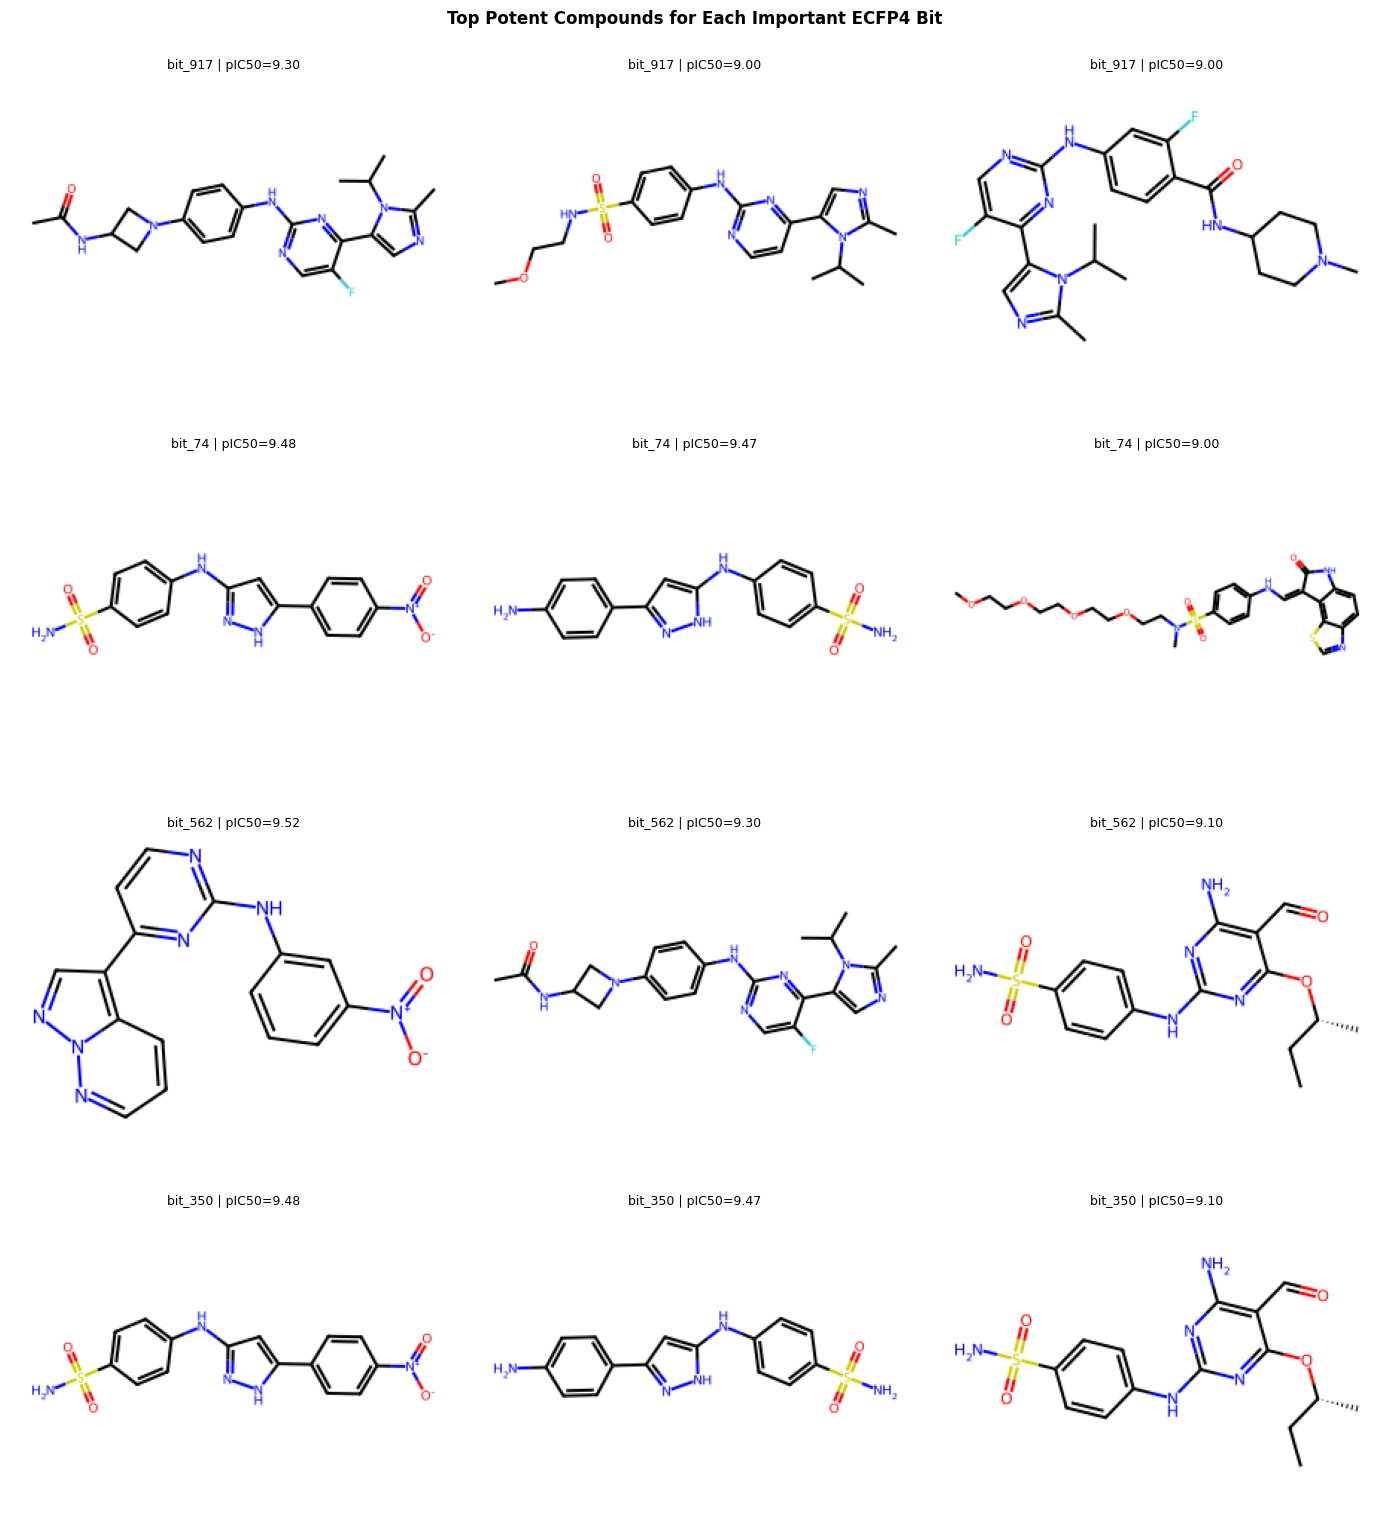

Plot saved


In [14]:
from rdkit.Chem import Draw
from IPython.display import display

# Get a representative potent compound for each bit
important_bits = [917, 74, 562, 350]
fig, axes = plt.subplots(len(important_bits), 3, figsize=(14, 4*len(important_bits)))

for row, bit in enumerate(important_bits):
    # Find potent compounds with this bit set
    bit_set = [i for i in range(len(y)) if X[i, bit] == 1]
    bit_set_sorted = sorted(bit_set, key=lambda i: y[i], reverse=True)
    
    # Draw top 3 most potent compounds with this bit
    for col, idx in enumerate(bit_set_sorted[:3]):
        smi = df['canonical_smiles'].iloc[valid_idx[idx]]
        mol = Chem.MolFromSmiles(smi)
        img = Draw.MolToImage(mol, size=(300, 200))
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'bit_{bit} | pIC50={y[idx]:.2f}', fontsize=9)
        axes[row, col].axis('off')
    
    axes[row, 0].set_ylabel(f'ECFP4_bit_{bit}\n'
                            f'n={len(bit_set)} ({100*len(bit_set)/len(y):.1f}%)\n'
                            f'Δ pIC50 = +{y[bit_set].mean() - y[[i for i in range(len(y)) if i not in bit_set]].mean():.2f}',
                            fontsize=8)

plt.suptitle('Top Potent Compounds for Each Important ECFP4 Bit', fontweight='bold')
plt.tight_layout()
plt.savefig('ecfp4_bit_compounds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [15]:
from rdkit.Chem import MolFromSmarts

# Sulfonamide SMARTS pattern
sulfonamide = MolFromSmarts('[#6][S](=[O])(=[O])[NH]')
sulfonyl = MolFromSmarts('[#6][S](=[O])(=[O])[#6]')  # broader sulfonyl

important_bits = [917, 74, 562, 350]

print("Sulfonamide/sulfonyl enrichment analysis\n")
print(f"{'Bit':<15} {'% with bit':<15} {'% SA in bit':<20} {'% SA without':<20} {'Enrichment'}")
print("-" * 80)

for bit in important_bits:
    bit_set     = [i for i in range(len(y)) if X[i, bit] == 1]
    no_bit_set  = [i for i in range(len(y)) if X[i, bit] == 0]
    
    # Check sulfonamide presence
    def has_sulfonamide(idx_list):
        count = 0
        for i in idx_list:
            smi = df['canonical_smiles'].iloc[valid_idx[i]]
            mol = Chem.MolFromSmiles(smi)
            if mol and mol.HasSubstructMatch(sulfonamide):
                count += 1
        return count
    
    sa_with    = has_sulfonamide(bit_set)
    sa_without = has_sulfonamide(no_bit_set)
    
    pct_with    = 100 * sa_with / len(bit_set)
    pct_without = 100 * sa_without / len(no_bit_set)
    enrichment  = pct_with / pct_without if pct_without > 0 else float('inf')
    
    print(f"bit_{bit:<10} {len(bit_set):<15} {pct_with:<20.1f} {pct_without:<20.1f} {enrichment:.2f}x")

Sulfonamide/sulfonyl enrichment analysis

Bit             % with bit      % SA in bit          % SA without         Enrichment
--------------------------------------------------------------------------------
bit_917        302             3.0                  3.4                  0.87x
bit_74         384             6.0                  2.7                  2.20x
bit_562        456             7.0                  2.3                  3.10x
bit_350        411             16.1                 0.1                  255.33x


=== ECFP4 bit_350 deep dive ===

Compounds WITH bit_350:    411
Compounds WITHOUT bit_350: 1590
Mean pIC50 WITH:    7.24
Mean pIC50 WITHOUT: 6.41
Median pIC50 WITH:    7.39
Median pIC50 WITHOUT: 6.42


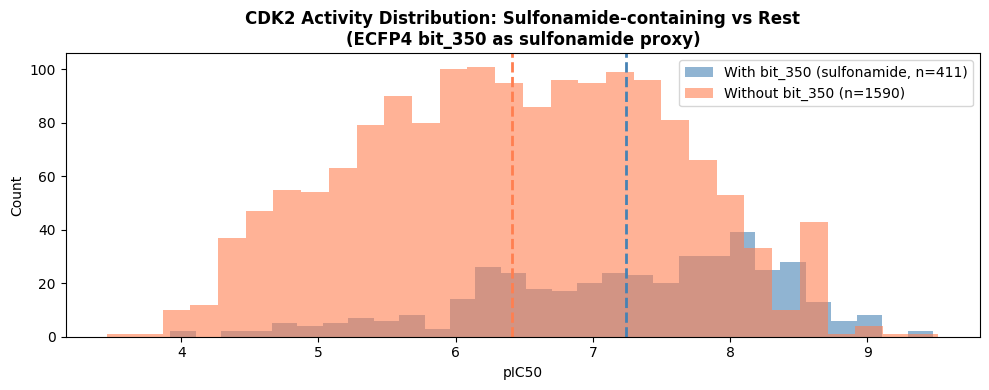


Sulfonamide potency advantage: +0.83 pIC50 units
That's a 6.8x improvement in IC50 on average


In [16]:
# Characterize bit_350 more thoroughly
bit_350_set = [i for i in range(len(y)) if X[i, 350] == 1]
bit_350_no  = [i for i in range(len(y)) if X[i, 350] == 0]

print("=== ECFP4 bit_350 deep dive ===\n")
print(f"Compounds WITH bit_350:    {len(bit_350_set)}")
print(f"Compounds WITHOUT bit_350: {len(bit_350_no)}")
print(f"Mean pIC50 WITH:    {y[bit_350_set].mean():.2f}")
print(f"Mean pIC50 WITHOUT: {y[bit_350_no].mean():.2f}")
print(f"Median pIC50 WITH:    {np.median(y[bit_350_set]):.2f}")
print(f"Median pIC50 WITHOUT: {np.median(y[bit_350_no]):.2f}")

# pIC50 distribution comparison
plt.figure(figsize=(10, 4))
plt.hist(y[bit_350_set], bins=30, alpha=0.6, color='steelblue', 
         label=f'With bit_350 (sulfonamide, n={len(bit_350_set)})')
plt.hist(y[bit_350_no],  bins=30, alpha=0.6, color='coral',    
         label=f'Without bit_350 (n={len(bit_350_no)})')
plt.axvline(y[bit_350_set].mean(), color='steelblue', linestyle='--', linewidth=2)
plt.axvline(y[bit_350_no].mean(),  color='coral',     linestyle='--', linewidth=2)
plt.xlabel('pIC50')
plt.ylabel('Count')
plt.title('CDK2 Activity Distribution: Sulfonamide-containing vs Rest\n'
          '(ECFP4 bit_350 as sulfonamide proxy)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('bit350_sulfonamide_activity.png', dpi=150, bbox_inches='tight')
plt.show()

# Show the delta clearly
delta = y[bit_350_set].mean() - y[bit_350_no].mean()
print(f"\nSulfonamide potency advantage: +{delta:.2f} pIC50 units")
print(f"That's a {10**delta:.1f}x improvement in IC50 on average")

In [17]:
# Final summary cell - print everything cleanly
print("=" * 55)
print("CDK2 QSAR MODEL — SUMMARY")
print("=" * 55)
print(f"\nDataset")
print(f"  Source:          ChEMBL (CHEMBL301)")
print(f"  Compounds:       {len(y):,}")
print(f"  Unique scaffolds:{len(scaffolds):,}")
print(f"  pIC50 range:     {y.min():.2f} - {y.max():.2f}")

print(f"\nFeaturization")
print(f"  ECFP4 bits:      1024 (radius=2)")
print(f"  PhysChem desc:   10 (RDKit)")
print(f"  Total features:  1034")

print(f"\nModel Performance (scaffold split test set, n={len(y_test)})")
print(f"  Random Forest:   R²={rf_r2:.3f} | RMSE={rf_rmse:.3f}")
print(f"  XGBoost:         R²={xgb_r2:.3f} | RMSE={xgb_rmse:.3f}")

print(f"\nKey SAR Finding")
print(f"  ECFP4 bit_350 encodes sulfonamide substructure")
print(f"  Sulfonamide compounds: mean pIC50 = 7.24 (n=411)")
print(f"  Non-sulfonamide:       mean pIC50 = 6.41 (n=1590)")
delta = 7.24 - 6.41
print(f"  Potency advantage:     +{delta:.2f} pIC50 = {10**delta:.1f}x improvement")
print(f"  Top SHAP features:     MolWt, TPSA (physicochemical)")
print(f"                         bits 917, 74, 562, 350 (structural)")
print("=" * 55)

CDK2 QSAR MODEL — SUMMARY

Dataset
  Source:          ChEMBL (CHEMBL301)
  Compounds:       2,001
  Unique scaffolds:857
  pIC50 range:     3.46 - 9.52

Featurization
  ECFP4 bits:      1024 (radius=2)
  PhysChem desc:   10 (RDKit)
  Total features:  1034

Model Performance (scaffold split test set, n=401)
  Random Forest:   R²=0.362 | RMSE=0.980
  XGBoost:         R²=0.389 | RMSE=0.959

Key SAR Finding
  ECFP4 bit_350 encodes sulfonamide substructure
  Sulfonamide compounds: mean pIC50 = 7.24 (n=411)
  Non-sulfonamide:       mean pIC50 = 6.41 (n=1590)
  Potency advantage:     +0.83 pIC50 = 6.8x improvement
  Top SHAP features:     MolWt, TPSA (physicochemical)
                         bits 917, 74, 562, 350 (structural)


In [18]:
# Print requirements for the repo
reqs = [
    "rdkit>=2023.9.0",
    "chembl-webresource-client>=0.10.8",
    "scikit-learn>=1.3.0",
    "xgboost>=2.0.0",
    "shap>=0.44.0",
    "pandas>=2.0.0",
    "numpy>=1.24.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.12.0",
    "jupyter>=1.0.0"
]

for r in reqs:
    print(r)

rdkit>=2023.9.0
chembl-webresource-client>=0.10.8
scikit-learn>=1.3.0
xgboost>=2.0.0
shap>=0.44.0
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
jupyter>=1.0.0


In [19]:
# Check nitroaromatic enrichment across important bits
nitro = Chem.MolFromSmarts('[c][N+](=O)[O-]')  # aromatic nitro
nitro_aliph = Chem.MolFromSmarts('[C][N+](=O)[O-]')  # aliphatic nitro

print("Nitroaromatic enrichment analysis\n")
print(f"{'Bit':<15} {'n with bit':<15} {'% nitro in bit':<20} {'% nitro without':<20} {'Enrichment'}")
print("-" * 80)

for bit in important_bits:
    bit_set    = [i for i in range(len(y)) if X[i, bit] == 1]
    no_bit_set = [i for i in range(len(y)) if X[i, bit] == 0]
    
    def has_nitro(idx_list):
        count = 0
        for i in idx_list:
            smi = df['canonical_smiles'].iloc[valid_idx[i]]
            mol = Chem.MolFromSmiles(smi)
            if mol and mol.HasSubstructMatch(nitro):
                count += 1
        return count
    
    nitro_with    = has_nitro(bit_set)
    nitro_without = has_nitro(no_bit_set)
    
    pct_with    = 100 * nitro_with / len(bit_set)
    pct_without = 100 * nitro_without / len(no_bit_set) if len(no_bit_set) > 0 else 0
    enrichment  = pct_with / pct_without if pct_without > 0 else float('inf')
    
    print(f"bit_{bit:<10} {len(bit_set):<15} {pct_with:<20.1f} {pct_without:<20.1f} {enrichment:.2f}x")

# Overall nitro prevalence in dataset
total_nitro = sum(1 for i in range(len(y)) 
                  if Chem.MolFromSmiles(df['canonical_smiles'].iloc[valid_idx[i]]).HasSubstructMatch(nitro))
print(f"\nOverall nitroaromatic prevalence in dataset: {total_nitro} compounds ({100*total_nitro/len(y):.1f}%)")
print(f"Mean pIC50 nitroaromatic compounds: ", end="")
nitro_idx = [i for i in range(len(y)) 
             if Chem.MolFromSmiles(df['canonical_smiles'].iloc[valid_idx[i]]).HasSubstructMatch(nitro)]
print(f"{y[nitro_idx].mean():.2f} (n={len(nitro_idx)})")
print(f"Mean pIC50 non-nitroaromatic:        {y[[i for i in range(len(y)) if i not in nitro_idx]].mean():.2f}")

Nitroaromatic enrichment analysis

Bit             n with bit      % nitro in bit       % nitro without      Enrichment
--------------------------------------------------------------------------------
bit_917        302             0.0                  3.1                  0.00x
bit_74         384             2.6                  2.6                  1.00x
bit_562        456             0.4                  3.2                  0.14x
bit_350        411             1.2                  3.0                  0.41x

Overall nitroaromatic prevalence in dataset: 52 compounds (2.6%)
Mean pIC50 nitroaromatic compounds: 5.65 (n=52)
Mean pIC50 non-nitroaromatic:        6.61


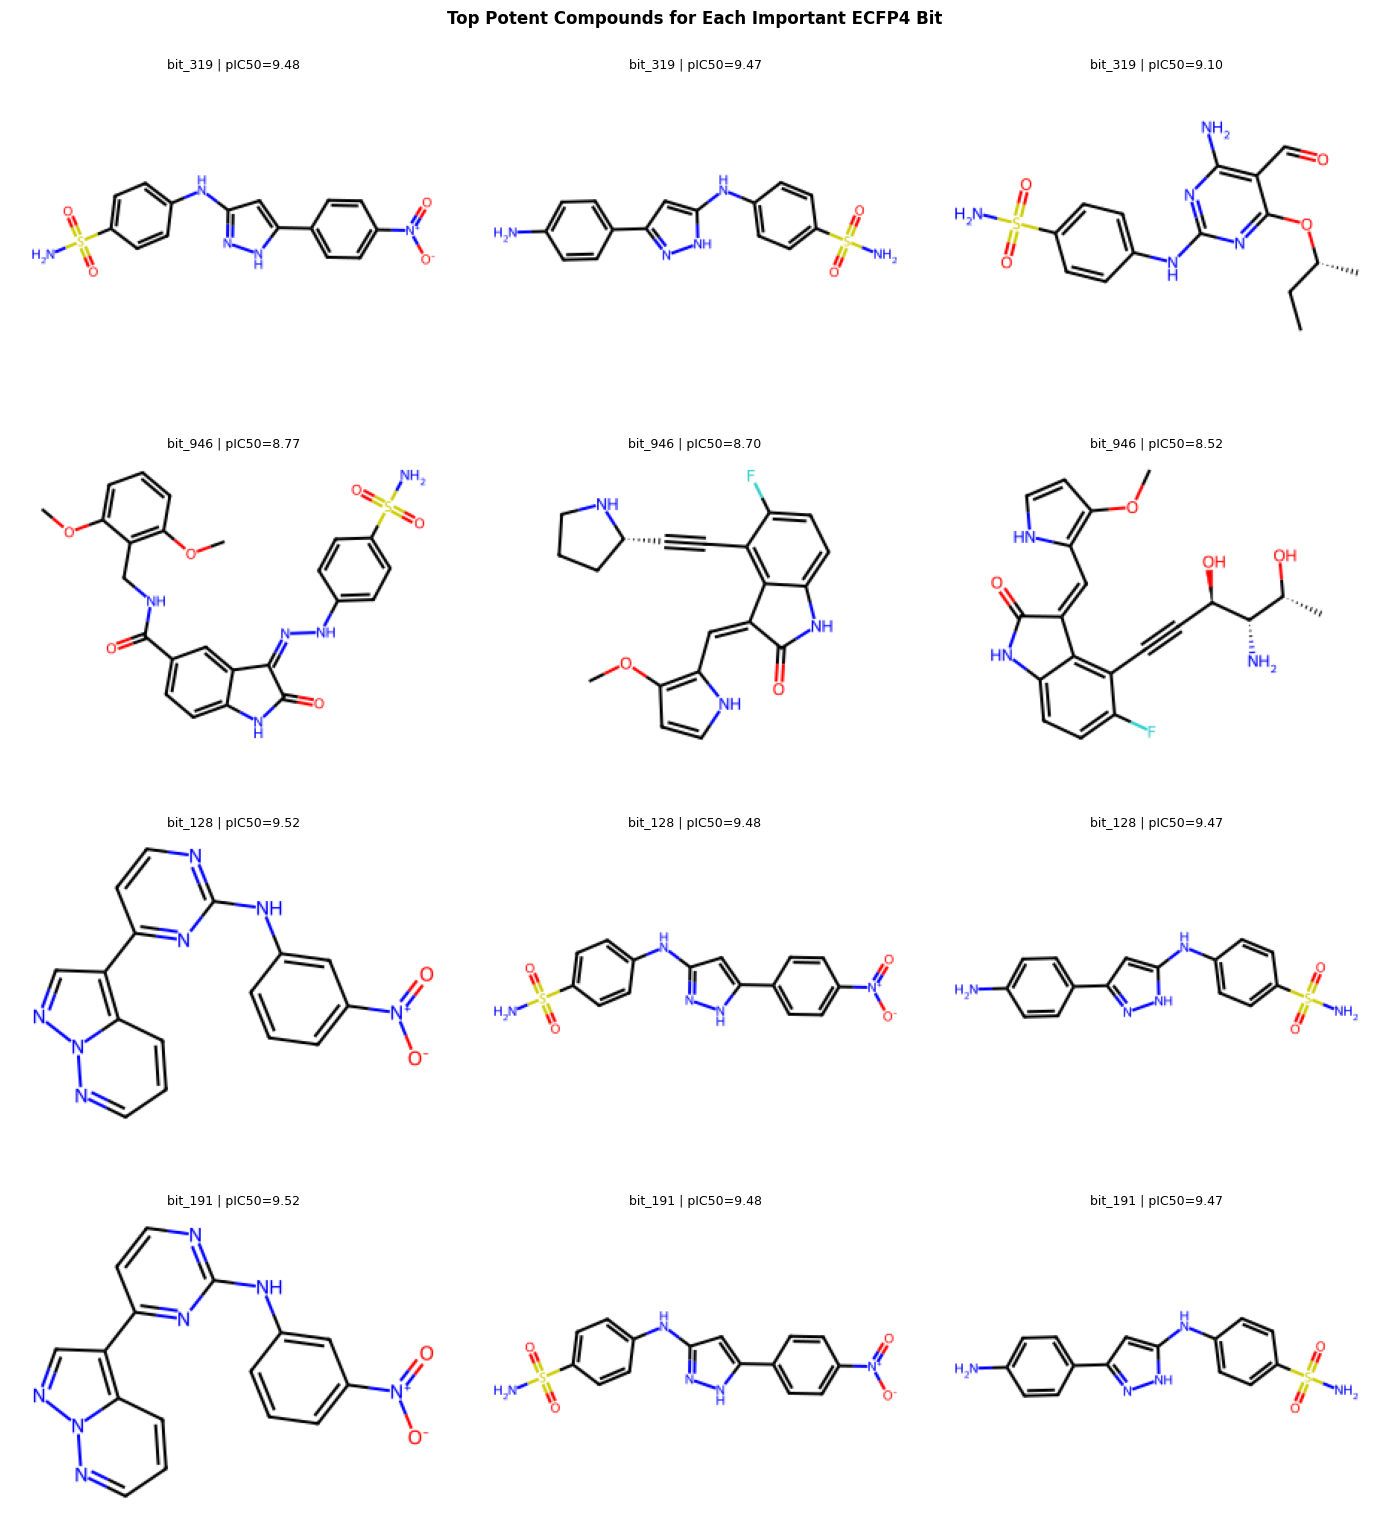

Plot saved


In [20]:
from rdkit.Chem import Draw
from IPython.display import display

# Get a representative potent compound for each bit
important_bits = [319, 946, 128, 191]
fig, axes = plt.subplots(len(important_bits), 3, figsize=(14, 4*len(important_bits)))

for row, bit in enumerate(important_bits):
    # Find potent compounds with this bit set
    bit_set = [i for i in range(len(y)) if X[i, bit] == 1]
    bit_set_sorted = sorted(bit_set, key=lambda i: y[i], reverse=True)
    
    # Draw top 3 most potent compounds with this bit
    for col, idx in enumerate(bit_set_sorted[:3]):
        smi = df['canonical_smiles'].iloc[valid_idx[idx]]
        mol = Chem.MolFromSmiles(smi)
        img = Draw.MolToImage(mol, size=(300, 200))
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'bit_{bit} | pIC50={y[idx]:.2f}', fontsize=9)
        axes[row, col].axis('off')
    
    axes[row, 0].set_ylabel(f'ECFP4_bit_{bit}\n'
                            f'n={len(bit_set)} ({100*len(bit_set)/len(y):.1f}%)\n'
                            f'Δ pIC50 = +{y[bit_set].mean() - y[[i for i in range(len(y)) if i not in bit_set]].mean():.2f}',
                            fontsize=8)

plt.suptitle('Top Potent Compounds for Each Important ECFP4 Bit', fontweight='bold')
plt.tight_layout()
plt.savefig('ecfp4_bit_compounds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [21]:
from rdkit.Chem import MolFromSmarts

# Sulfonamide SMARTS pattern
sulfonamide = MolFromSmarts('[#6][S](=[O])(=[O])[NH]')
sulfonyl = MolFromSmarts('[#6][S](=[O])(=[O])[#6]')  # broader sulfonyl

important_bits = [319, 946, 128, 191]

print("Sulfonamide/sulfonyl enrichment analysis\n")
print(f"{'Bit':<15} {'% with bit':<15} {'% SA in bit':<20} {'% SA without':<20} {'Enrichment'}")
print("-" * 80)

for bit in important_bits:
    bit_set     = [i for i in range(len(y)) if X[i, bit] == 1]
    no_bit_set  = [i for i in range(len(y)) if X[i, bit] == 0]
    
    # Check sulfonamide presence
    def has_sulfonamide(idx_list):
        count = 0
        for i in idx_list:
            smi = df['canonical_smiles'].iloc[valid_idx[i]]
            mol = Chem.MolFromSmiles(smi)
            if mol and mol.HasSubstructMatch(sulfonamide):
                count += 1
        return count
    
    sa_with    = has_sulfonamide(bit_set)
    sa_without = has_sulfonamide(no_bit_set)
    
    pct_with    = 100 * sa_with / len(bit_set)
    pct_without = 100 * sa_without / len(no_bit_set)
    enrichment  = pct_with / pct_without if pct_without > 0 else float('inf')
    
    print(f"bit_{bit:<10} {len(bit_set):<15} {pct_with:<20.1f} {pct_without:<20.1f} {enrichment:.2f}x")

Sulfonamide/sulfonyl enrichment analysis

Bit             % with bit      % SA in bit          % SA without         Enrichment
--------------------------------------------------------------------------------
bit_319        304             19.4                 0.5                  41.17x
bit_946        214             0.5                  3.7                  0.13x
bit_128        1625            4.1                  0.3                  15.27x
bit_191        758             7.9                  0.6                  14.06x


In [22]:
# Complete sulfonamide bit analysis - all bits we've checked
all_bits = [917, 74, 562, 350, 319, 946, 128, 191]

print("Complete sulfonamide enrichment summary\n")
print(f"{'Bit':<12} {'n':<8} {'% SA with':<14} {'% SA without':<16} {'Enrichment':<12} {'Mean pIC50 with':<18} {'Mean pIC50 without'}")
print("-" * 100)

for bit in all_bits:
    bit_set    = [i for i in range(len(y)) if X[i, bit] == 1]
    no_bit_set = [i for i in range(len(y)) if X[i, bit] == 0]
    
    sa_with    = sum(1 for i in bit_set if Chem.MolFromSmiles(
        df['canonical_smiles'].iloc[valid_idx[i]]).HasSubstructMatch(sulfonamide))
    sa_without = sum(1 for i in no_bit_set if Chem.MolFromSmiles(
        df['canonical_smiles'].iloc[valid_idx[i]]).HasSubstructMatch(sulfonamide))
    
    pct_with    = 100 * sa_with / len(bit_set)
    pct_without = 100 * sa_without / len(no_bit_set) if no_bit_set else 0
    enrichment  = pct_with / pct_without if pct_without > 0 else float('inf')
    
    mean_with    = y[bit_set].mean()
    mean_without = y[no_bit_set].mean()
    
    flag = " <-- SULFONAMIDE" if enrichment > 10 else ""
    print(f"bit_{bit:<8} {len(bit_set):<8} {pct_with:<14.1f} {pct_without:<16.1f} "
          f"{enrichment:<12.2f} {mean_with:<18.2f} {mean_without:.2f}{flag}")

# Summary of sulfonamide-encoding bits
sa_bits = [b for b in all_bits if b != 946]  # exclude the depleted one
print(f"\nSulfonamide-associated bits identified: {[b for b in all_bits if b not in [946]]}")
print(f"\nNote: bit_128 present in {sum(X[:,128]):.0f} compounds ({100*sum(X[:,128])/len(y):.1f}%)")
print("      This is likely encoding a broader aromatic sulfonyl rather than")
print("      strictly sulfonamide - worth visual inspection")

Complete sulfonamide enrichment summary

Bit          n        % SA with      % SA without     Enrichment   Mean pIC50 with    Mean pIC50 without
----------------------------------------------------------------------------------------------------
bit_917      302      3.0            3.4              0.87         7.28               6.46
bit_74       384      6.0            2.7              2.20         6.99               6.49
bit_562      456      7.0            2.3              3.10         7.01               6.46
bit_350      411      16.1           0.1              255.33       7.24               6.41 <-- SULFONAMIDE
bit_319      304      19.4           0.5              41.17        7.42               6.43 <-- SULFONAMIDE
bit_946      214      0.5            3.7              0.13         6.03               6.65
bit_128      1625     4.1            0.3              15.27        6.72               6.00 <-- SULFONAMIDE
bit_191      758      7.9            0.6              14.06        6

In [23]:
# Investigate bit_128 - what substructures correlate with it?
bit128_set = [i for i in range(len(y)) if X[i, 128] == 1]
bit128_no  = [i for i in range(len(y)) if X[i, 128] == 0]

print(f"bit_128 present in {len(bit128_set)} compounds ({100*len(bit128_set)/len(y):.1f}%)")
print(f"bit_128 absent in  {len(bit128_no)} compounds ({100*len(bit128_no)/len(y):.1f}%)")
print(f"\nMean pIC50 with:    {y[bit128_set].mean():.2f}")
print(f"Mean pIC50 without: {y[bit128_no].mean():.2f}")
print(f"Potency advantage:  +{y[bit128_set].mean()-y[bit128_no].mean():.2f} pIC50 = "
      f"{10**(y[bit128_set].mean()-y[bit128_no].mean()):.1f}x\n")

# Test common CDK2 pharmacophore patterns
patterns = {
    'Pyrimidine':          '[n]1[c][n][c][c][c]1',
    'Purine/adenine core': 'c1ncnc2[nH]cnc12',
    'Aniline (NH-Ar)':     '[NH][c]',
    'Urea':                '[NH]C(=O)[NH]',
    'Amide':               'C(=O)[NH]',
    'Pyridine':            'n1ccccc1',
    'Piperazine':          'N1CCNCC1',
    'Indole':              'c1ccc2[nH]ccc2c1',
    'Benzimidazole':       'c1ccc2[nH]cnc2c1',
    'Sulfonamide':         '[#6][S](=[O])(=[O])[NH]',
    'Any nitrogen heteroarom': 'n',
}

print(f"{'Pattern':<25} {'% in bit128':<16} {'% outside':<16} {'Enrichment'}")
print("-" * 70)

for name, smarts in patterns.items():
    try:
        patt = Chem.MolFromSmarts(smarts)
        if patt is None:
            continue
        
        in_bit  = sum(1 for i in bit128_set 
                      if Chem.MolFromSmiles(df['canonical_smiles'].iloc[valid_idx[i]])
                      .HasSubstructMatch(patt))
        out_bit = sum(1 for i in bit128_no  
                      if Chem.MolFromSmiles(df['canonical_smiles'].iloc[valid_idx[i]])
                      .HasSubstructMatch(patt))
        
        pct_in  = 100 * in_bit  / len(bit128_set)
        pct_out = 100 * out_bit / len(bit128_no) if bit128_no else 0
        enrich  = pct_in / pct_out if pct_out > 0 else float('inf')
        
        print(f"{name:<25} {pct_in:<16.1f} {pct_out:<16.1f} {enrich:.2f}x")
    except:
        print(f"{name:<25} ERROR")

bit_128 present in 1625 compounds (81.2%)
bit_128 absent in  376 compounds (18.8%)

Mean pIC50 with:    6.72
Mean pIC50 without: 6.00
Potency advantage:  +0.72 pIC50 = 5.3x

Pattern                   % in bit128      % outside        Enrichment
----------------------------------------------------------------------
Pyrimidine                56.6             24.2             2.34x
Purine/adenine core       0.6              0.0              infx
Aniline (NH-Ar)           93.4             22.6             4.13x
Urea                      1.4              0.0              infx
Amide                     45.0             25.3             1.78x
Pyridine                  35.1             26.6             1.32x
Piperazine                10.0             9.3              1.08x
Indole                    3.2              3.2              1.00x
Benzimidazole             1.0              6.4              0.15x
Sulfonamide               4.1              0.3              15.27x
Any nitrogen heteroarom  

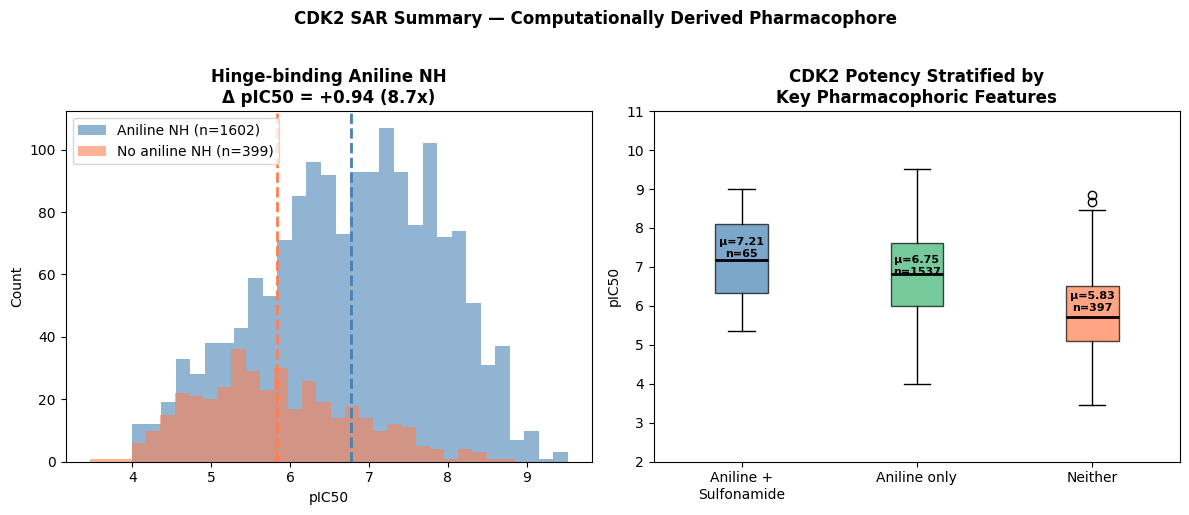

CDK2 Potency by Pharmacophoric Group
---------------------------------------------
Aniline + Sulfonamide     n=65     mean pIC50=7.21
Aniline only              n=1537   mean pIC50=6.75
Neither                   n=397    mean pIC50=5.83


In [24]:
# Final SAR interpretation cell
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Activity by aniline presence
aniline = Chem.MolFromSmarts('[NH][c]')
aniline_idx = [i for i in range(len(y)) 
               if Chem.MolFromSmiles(df['canonical_smiles'].iloc[valid_idx[i]])
               .HasSubstructMatch(aniline)]
no_aniline_idx = [i for i in range(len(y)) if i not in aniline_idx]

axes[0].hist(y[aniline_idx],    bins=30, alpha=0.6, 
             color='steelblue', label=f'Aniline NH (n={len(aniline_idx)})')
axes[0].hist(y[no_aniline_idx], bins=30, alpha=0.6, 
             color='coral',     label=f'No aniline NH (n={len(no_aniline_idx)})')
axes[0].axvline(y[aniline_idx].mean(),    color='steelblue', linestyle='--', linewidth=2)
axes[0].axvline(y[no_aniline_idx].mean(), color='coral',     linestyle='--', linewidth=2)
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Hinge-binding Aniline NH\n'
                  f'Δ pIC50 = +{y[aniline_idx].mean()-y[no_aniline_idx].mean():.2f} '
                  f'({10**(y[aniline_idx].mean()-y[no_aniline_idx].mean()):.1f}x)',
                  fontweight='bold')
axes[0].legend()

# Plot 2: Combined aniline + sulfonamide stratification
both_idx    = [i for i in aniline_idx 
               if Chem.MolFromSmiles(df['canonical_smiles'].iloc[valid_idx[i]])
               .HasSubstructMatch(sulfonamide)]
ani_only    = [i for i in aniline_idx    if i not in both_idx]
neither_idx = [i for i in no_aniline_idx 
               if not Chem.MolFromSmiles(df['canonical_smiles'].iloc[valid_idx[i]])
               .HasSubstructMatch(sulfonamide)]

groups = {
    'Aniline +\nSulfonamide': both_idx,
    'Aniline only':           ani_only,
    'Neither':                neither_idx
}

colors = ['steelblue', 'mediumseagreen', 'coral']
positions = range(len(groups))

bp = axes[1].boxplot(
    [y[idx] for idx in groups.values()],
    labels=groups.keys(),
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, (name, idx) in enumerate(groups.items()):
    axes[1].text(i+1, y[idx].mean(), f'μ={y[idx].mean():.2f}\nn={len(idx)}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[1].set_ylabel('pIC50')
axes[1].set_title('CDK2 Potency Stratified by\nKey Pharmacophoric Features',
                  fontweight='bold')
axes[1].set_ylim(2, 11)

plt.suptitle('CDK2 SAR Summary — Computationally Derived Pharmacophore',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sar_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the numbers
print("CDK2 Potency by Pharmacophoric Group")
print("-" * 45)
for name, idx in groups.items():
    print(f"{name.replace(chr(10),' '):<25} "
          f"n={len(idx):<6} mean pIC50={y[idx].mean():.2f}")